In [61]:
import os
import pandas as pd
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u_astropy
from reproject import reproject_exact   # pip install reproject if missing

NATIVE_MAS = 20    # grizli mosaic 原始像素尺度 (mas/pixel)
TARGET_MAS  = 30   # 目标输出分辨率 (mas/pixel)
HALF_PIX    = 50   # 原始切图半径 (pixels @ 20mas，覆盖 1")

df = pd.read_csv("jda_low_res.csv")
#check all column names
print(df.columns)

Index(['file', 'srcid', 'ra', 'dec', 'grating', 'filter', 'effexptm', 'nfiles',
       'dataset', 'msamet',
       ...
       'beta_wlo', 'beta_whi', 'beta_nmad', 'dla_npix', 'dla_value', 'dla_unc',
       'beta_cov_00', 'beta_cov_01', 'beta_cov_10', 'beta_cov_11'],
      dtype='object', length=587)


In [62]:
#unique file_phot, remove nan
root_original = df['file_phot'].unique()
#remove nan
root_original = [x for x in root_original if pd.notna(x)]

#loop through all root test
root = []
root_var = []
for index in range(len(root_original)):
    #skip nan
    if pd.isna(root_original[index]):
        continue
    else:
        root.append(root_original[index].replace('-fix_phot', '-f150w-clear_drc_sci')+'.gz')
print(root)
print(root_original)

['abell2744clu-grizli-v7.2-f150w-clear_drc_sci.fits.gz', 'abell2744par-grizli-v7.0-f150w-clear_drc_sci.fits.gz', 'abell370-full-grizli-v7.1-f150w-clear_drc_sci.fits.gz', 'primer-cosmos-east-grizli-v7.4-f150w-clear_drc_sci.fits.gz', 'cweb-20250607-grizli-v7.5-f150w-clear_drc_sci.fits.gz', 'primer-cosmos-west-grizli-v7.4-f150w-clear_drc_sci.fits.gz', 'ceers-full-grizli-v7.4-f150w-clear_drc_sci.fits.gz', 'primer-uds-south-grizli-v7.2-f150w-clear_drc_sci.fits.gz', 'primer-uds-north-grizli-v7.2-f150w-clear_drc_sci.fits.gz', 'gds-sw-grizli-v7.0-f150w-clear_drc_sci.fits.gz', 'gds-grizli-v7.2-f150w-clear_drc_sci.fits.gz', 'gdn-grizli-v7.4-f150w-clear_drc_sci.fits.gz', 'ngdeep-grizli-v7.2-f150w-clear_drc_sci.fits.gz', 'macs0416-clu-grizli-v7.0-f150w-clear_drc_sci.fits.gz', 'macs0417-full-grizli-v7.2-f150w-clear_drc_sci.fits.gz', 'macs1149-clu-grizli-v7.0-f150w-clear_drc_sci.fits.gz', 'macs1423-full-grizli-v7.2-f150w-clear_drc_sci.fits.gz', 'macs0647-grizli-v7.0-f150w-clear_drc_sci.fits.gz', 'rx

In [45]:
#try download all files in root to download_mosaic folder
from tqdm.auto import tqdm
os.makedirs('download_mosaic', exist_ok=True)

count = 0
for index in tqdm(range(len(root))):
    if os.path.exists('download_mosaic/'+root[index].replace('.gz', '')):
        continue
    try:
        #download without cell output
        os.system('wget -P download_mosaic/ https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/'+root[index])
        #then unzip the file
        os.system('gunzip download_mosaic/'+root[index])
        count += 1
    except Exception as e:
        continue

  0%|          | 0/21 [00:00<?, ?it/s]

--2026-03-02 04:18:26--  https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/abell370-full-grizli-v7.1-f150w-clear_drc_sci.fits.gz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.169.216, 16.15.199.245, 16.15.218.19, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.169.216|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-03-02 04:18:27 ERROR 403: Forbidden.

gzip: download_mosaic/abell370-full-grizli-v7.1-f150w-clear_drc_sci.fits.gz: No such file or directory
--2026-03-02 04:18:27--  https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/cweb-20250607-grizli-v7.5-f150w-clear_drc_sci.fits.gz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.218.19, 16.15.199.245, 3.5.16.31, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.218.19|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-03-02 04:18:27 ERROR 403: Forbidden.

gzip: download_mosaic/cweb-20250607-grizli-v7.5-f150w-clear_drc_sci.fits.gz: No such fil

In [63]:
from astropy.io import fits
from matplotlib import pyplot as plt
index =1
with fits.open('download_mosaic/'+root[index].replace('.gz', '')) as hdul:
    hdu = hdul[0]
    #print(hdu.header.get('PIXFRAC'))
    #print headers
    #print(hdu.header.keys)
    #unit in nanoJy
    #


nJy/pixel → MJy/sr factor at 20mas: 0.1064


  0%|          | 0/20 [00:00<?, ?it/s]

-------------------
abell2744clu-grizli-v7.2-f150w-clear_drc_sci.fits.gz abell2744clu-grizli-v7.2-fix_phot.fits
Number of sources in catalog: 922
Randomly selected source: 177148
20mas cutout shape: (100, 100)
fraction of 0 in cutout: 0.0


/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


30mas cutout shape: (66, 66)
value range (MJy/sr): [-0.0010, 0.0061]


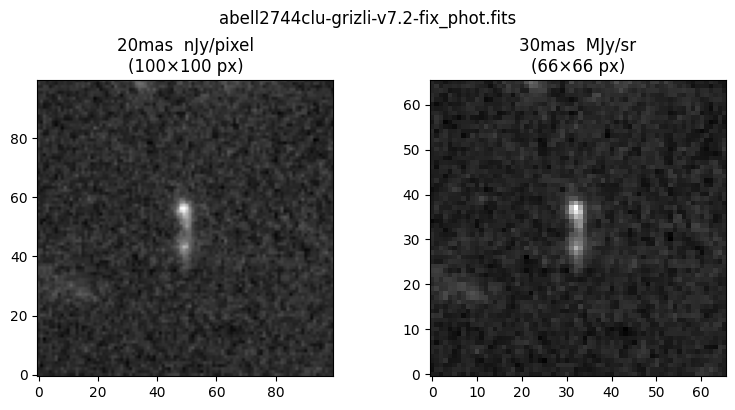

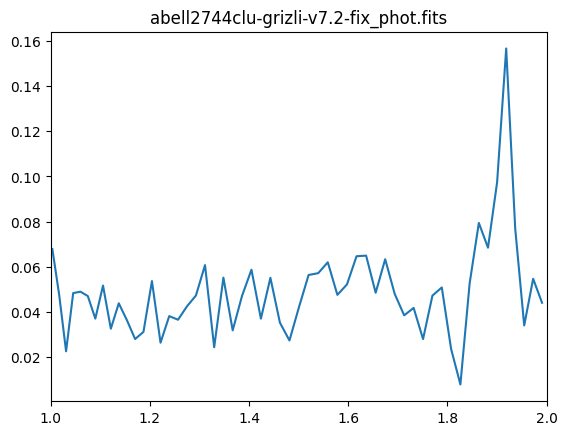

-------------------
abell2744par-grizli-v7.0-f150w-clear_drc_sci.fits.gz abell2744par-grizli-v7.0-fix_phot.fits
Number of sources in catalog: 36
Randomly selected source: 151887
20mas cutout shape: (100, 100)
fraction of 0 in cutout: 0.0


/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


30mas cutout shape: (66, 66)
value range (MJy/sr): [-0.0010, 0.0041]


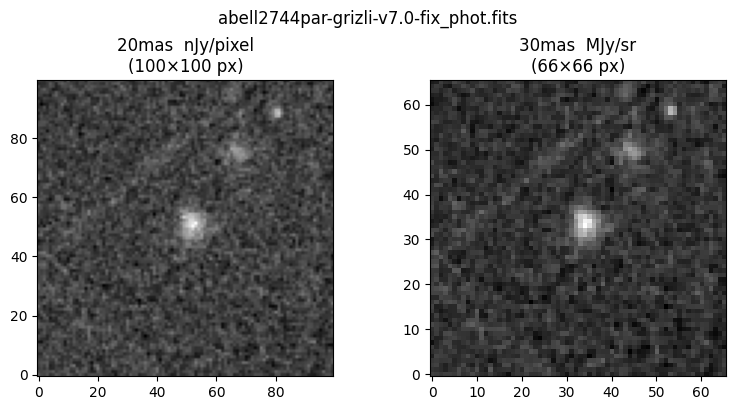

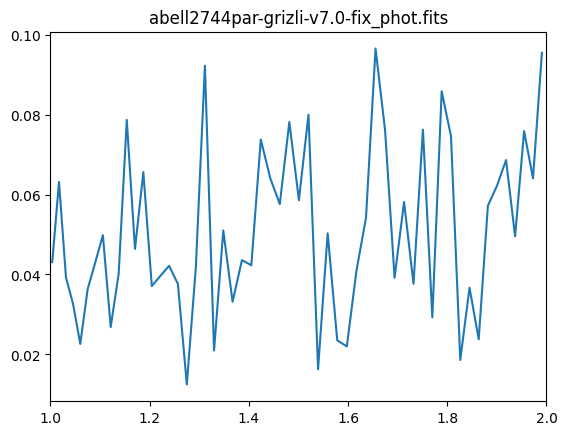

-------------------
abell370-full-grizli-v7.1-f150w-clear_drc_sci.fits.gz abell370-full-grizli-v7.1-fix_phot.fits
[Errno 2] No such file or directory: 'download_mosaic/abell370-full-grizli-v7.1-f150w-clear_drc_sci.fits'
-------------------
primer-cosmos-east-grizli-v7.4-f150w-clear_drc_sci.fits.gz primer-cosmos-east-grizli-v7.4-fix_phot.fits
Number of sources in catalog: 732
Randomly selected source: 143212
20mas cutout shape: (100, 100)
fraction of 0 in cutout: 0.0


/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


30mas cutout shape: (66, 66)
value range (MJy/sr): [-0.0057, 0.1402]


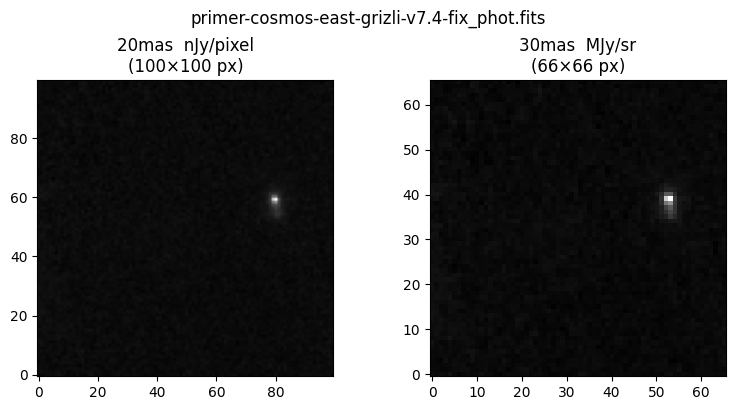

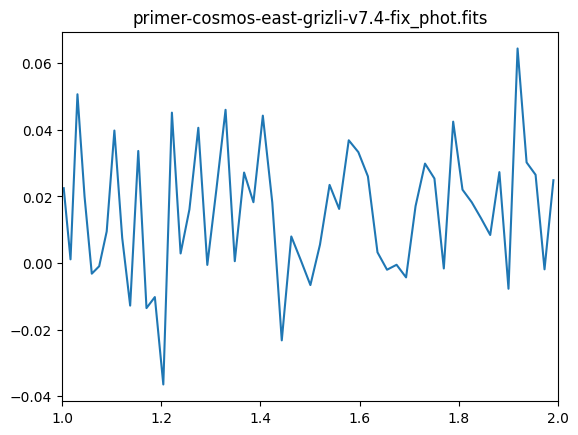

-------------------
cweb-20250607-grizli-v7.5-f150w-clear_drc_sci.fits.gz cweb-20250607-grizli-v7.5-fix_phot.fits
[Errno 2] No such file or directory: 'download_mosaic/cweb-20250607-grizli-v7.5-f150w-clear_drc_sci.fits'
-------------------
primer-cosmos-west-grizli-v7.4-f150w-clear_drc_sci.fits.gz primer-cosmos-west-grizli-v7.4-fix_phot.fits
Number of sources in catalog: 501
Randomly selected source: 161460
20mas cutout shape: (100, 100)
fraction of 0 in cutout: 0.0


/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


30mas cutout shape: (66, 66)
value range (MJy/sr): [-0.0053, 0.1581]


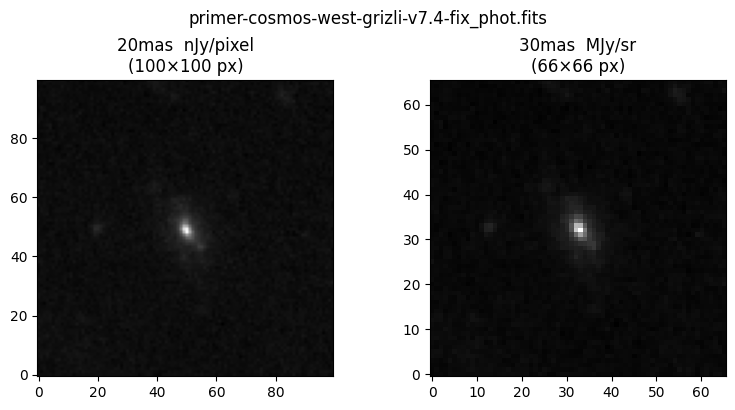

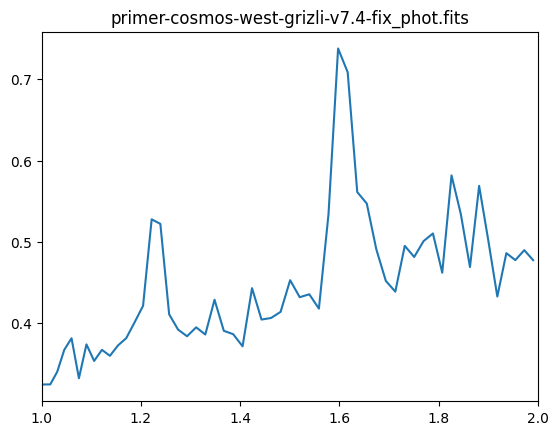

-------------------
ceers-full-grizli-v7.4-f150w-clear_drc_sci.fits.gz ceers-full-grizli-v7.4-fix_phot.fits
Number of sources in catalog: 3235
Randomly selected source: 139238
20mas cutout shape: (100, 100)
fraction of 0 in cutout: 0.0


/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


30mas cutout shape: (66, 66)
value range (MJy/sr): [-0.0057, 0.0077]


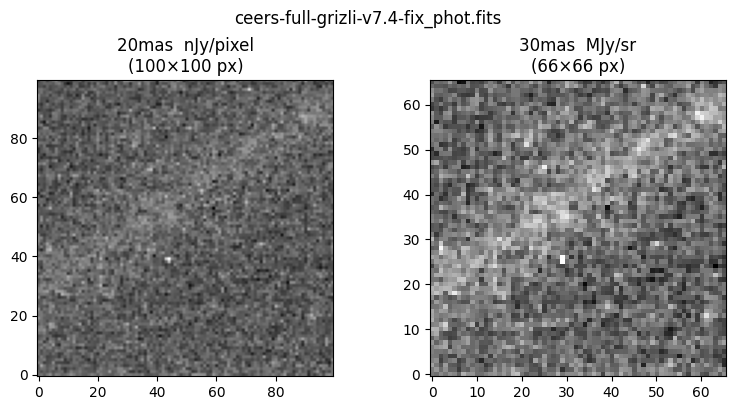

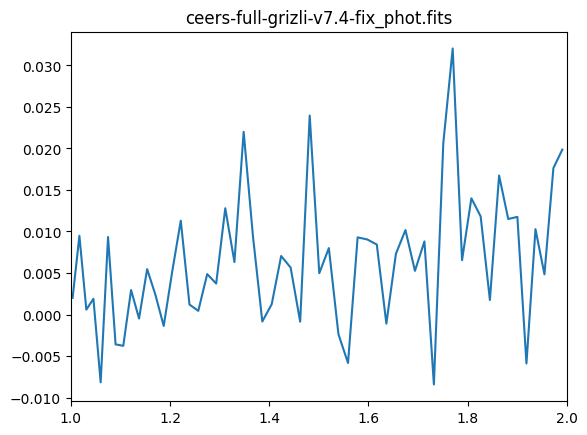

-------------------
primer-uds-south-grizli-v7.2-f150w-clear_drc_sci.fits.gz primer-uds-south-grizli-v7.2-fix_phot.fits
Number of sources in catalog: 1232
Randomly selected source: 163146
20mas cutout shape: (100, 100)
fraction of 0 in cutout: 0.0
30mas cutout shape: (66, 66)
value range (MJy/sr): [-0.0090, 0.0234]


/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


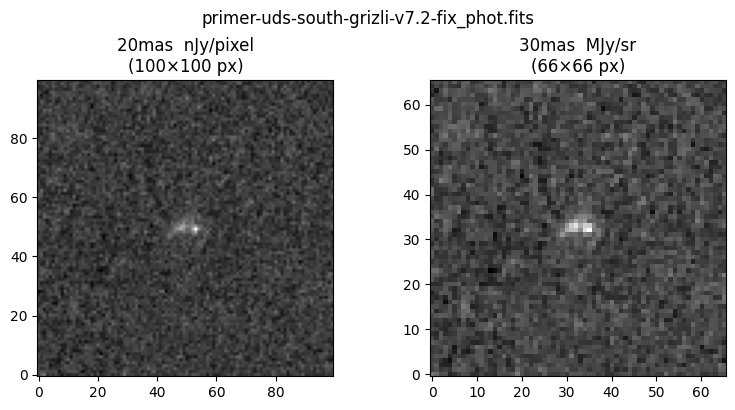

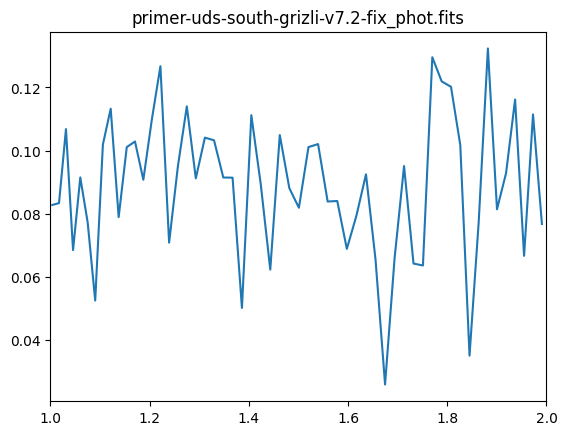

-------------------
primer-uds-north-grizli-v7.2-f150w-clear_drc_sci.fits.gz primer-uds-north-grizli-v7.2-fix_phot.fits
Number of sources in catalog: 1916
Randomly selected source: 162206
20mas cutout shape: (100, 100)
fraction of 0 in cutout: 0.0


/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


30mas cutout shape: (66, 66)
value range (MJy/sr): [-0.0095, 0.0200]


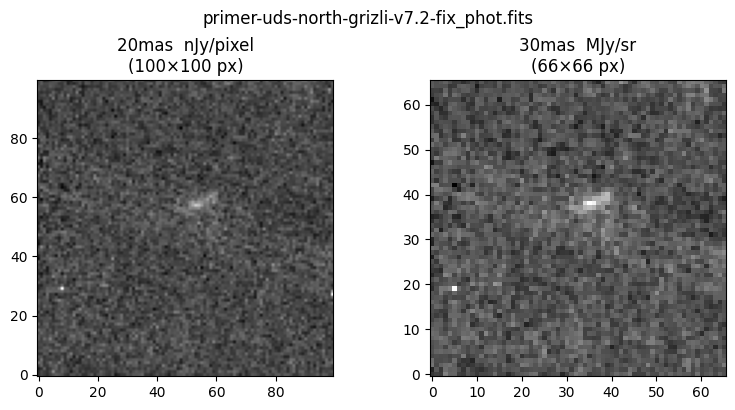

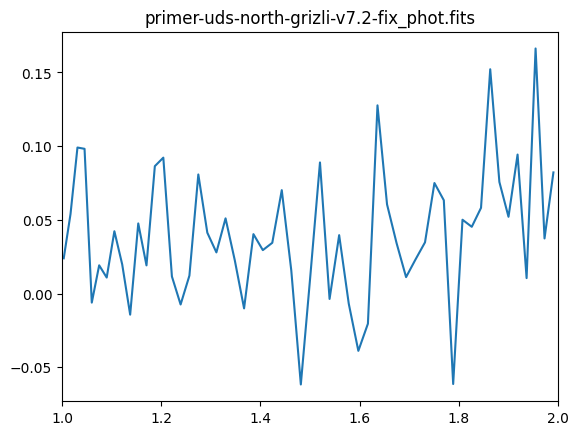

-------------------
gds-sw-grizli-v7.0-f150w-clear_drc_sci.fits.gz gds-sw-grizli-v7.0-fix_phot.fits
Number of sources in catalog: 1062
Randomly selected source: 148512
20mas cutout shape: (100, 100)
fraction of 0 in cutout: 0.0
30mas cutout shape: (66, 66)
value range (MJy/sr): [-0.0007, 0.0035]


/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


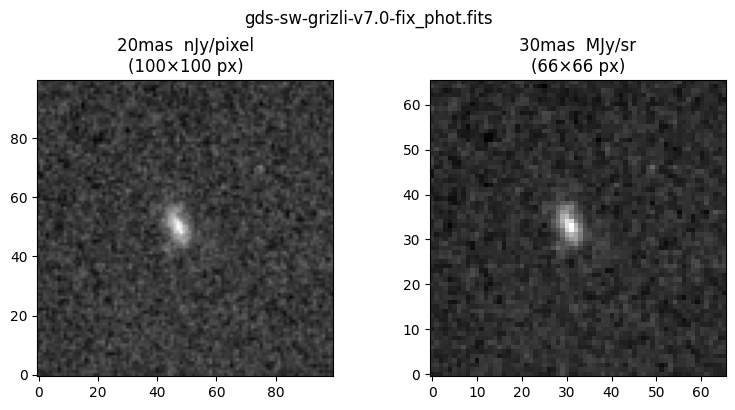

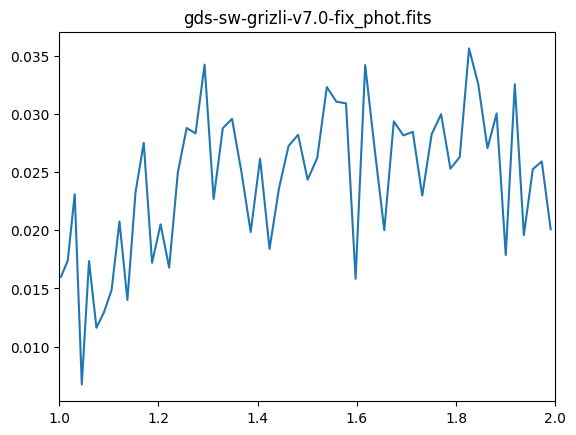

-------------------
gds-grizli-v7.2-f150w-clear_drc_sci.fits.gz gds-grizli-v7.2-fix_phot.fits
Number of sources in catalog: 1846
Randomly selected source: 172789
20mas cutout shape: (100, 100)
fraction of 0 in cutout: 0.0


/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


30mas cutout shape: (66, 66)
value range (MJy/sr): [-0.0005, 0.0245]


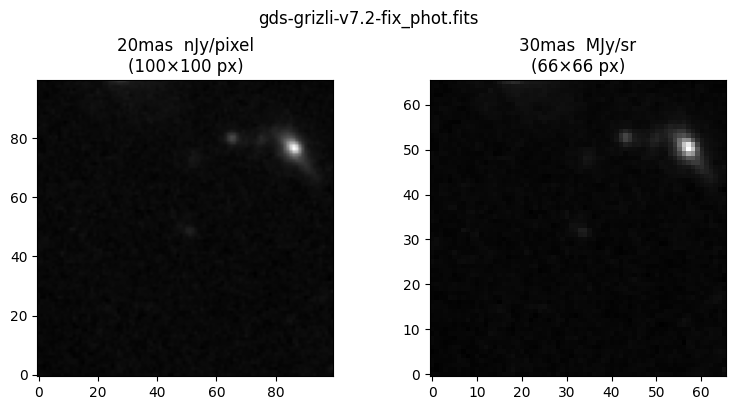

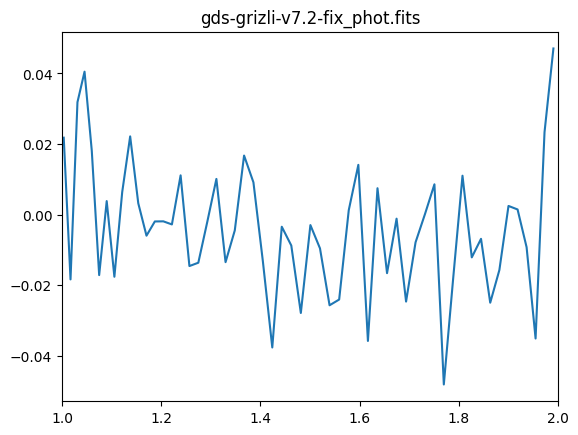

-------------------
gdn-grizli-v7.4-f150w-clear_drc_sci.fits.gz gdn-grizli-v7.4-fix_phot.fits
Number of sources in catalog: 2018
Randomly selected source: 174492
20mas cutout shape: (100, 100)
fraction of 0 in cutout: 1.0
30mas cutout shape: (66, 66)
value range (MJy/sr): [0.0000, 0.0000]


/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


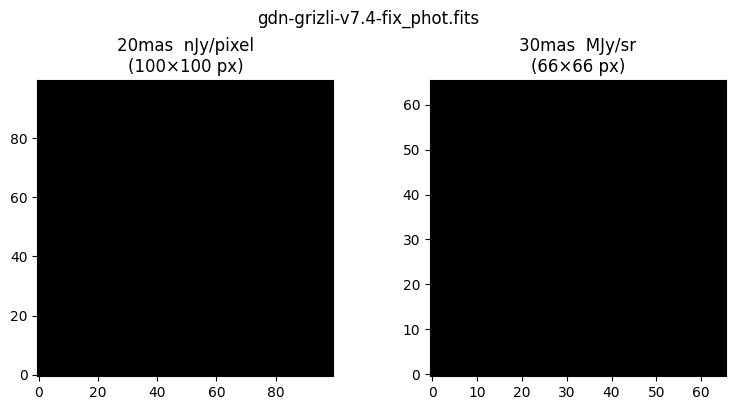

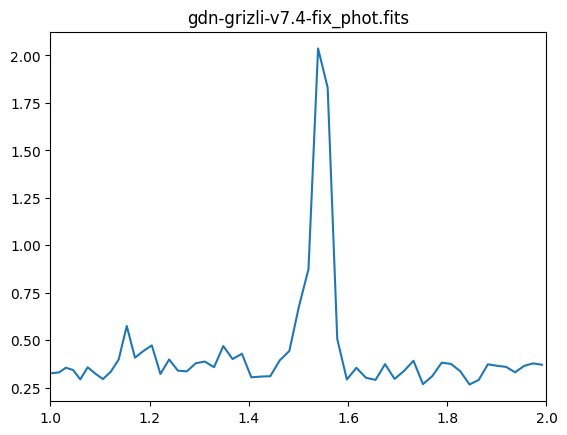

-------------------
ngdeep-grizli-v7.2-f150w-clear_drc_sci.fits.gz ngdeep-grizli-v7.2-fix_phot.fits
Number of sources in catalog: 1
Randomly selected source: 175396
20mas cutout shape: (100, 100)
fraction of 0 in cutout: 1.0
30mas cutout shape: (66, 66)
value range (MJy/sr): [0.0000, 0.0000]


/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


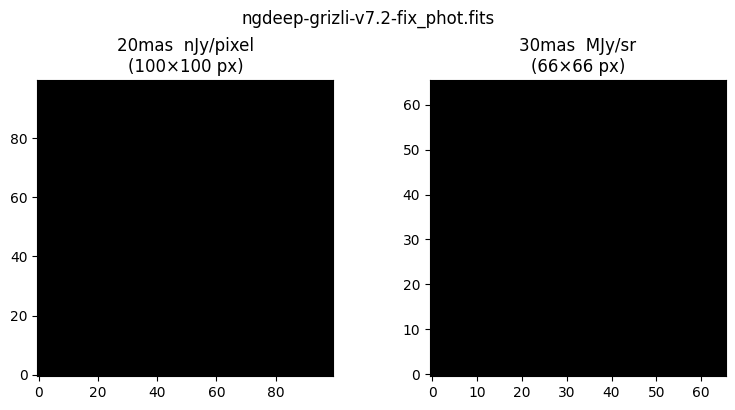

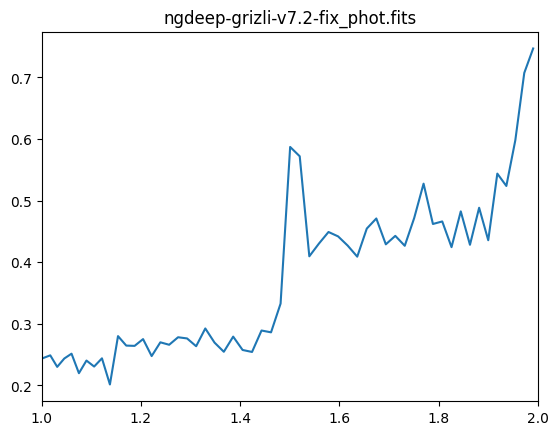

-------------------
macs0416-clu-grizli-v7.0-f150w-clear_drc_sci.fits.gz macs0416-clu-grizli-v7.0-fix_phot.fits
[Errno 2] No such file or directory: 'download_mosaic/macs0416-clu-grizli-v7.0-f150w-clear_drc_sci.fits'
-------------------
macs0417-full-grizli-v7.2-f150w-clear_drc_sci.fits.gz macs0417-full-grizli-v7.2-fix_phot.fits
[Errno 2] No such file or directory: 'download_mosaic/macs0417-full-grizli-v7.2-f150w-clear_drc_sci.fits'
-------------------
macs1149-clu-grizli-v7.0-f150w-clear_drc_sci.fits.gz macs1149-clu-grizli-v7.0-fix_phot.fits
[Errno 2] No such file or directory: 'download_mosaic/macs1149-clu-grizli-v7.0-f150w-clear_drc_sci.fits'
-------------------
macs1423-full-grizli-v7.2-f150w-clear_drc_sci.fits.gz macs1423-full-grizli-v7.2-fix_phot.fits
[Errno 2] No such file or directory: 'download_mosaic/macs1423-full-grizli-v7.2-f150w-clear_drc_sci.fits'
-------------------
macs0647-grizli-v7.0-f150w-clear_drc_sci.fits.gz macs0647-grizli-v7.0-fix_phot.fits
Number of sources in c

/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


30mas cutout shape: (66, 66)
value range (MJy/sr): [-0.0034, 0.0719]


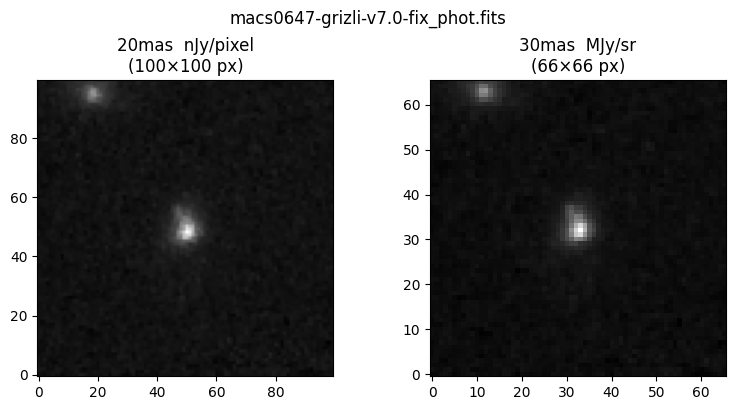

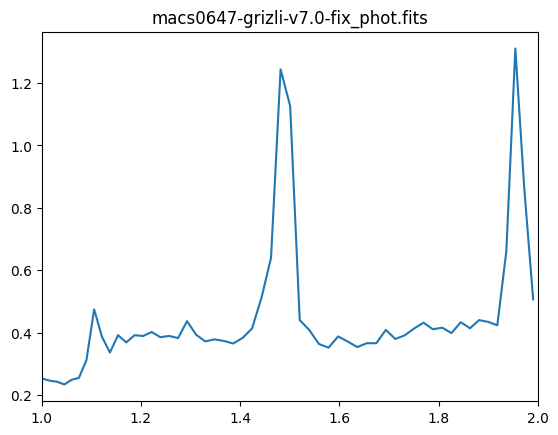

-------------------
rxj2129-grizli-v7.0-f150w-clear_drc_sci.fits.gz rxj2129-grizli-v7.0-fix_phot.fits
Number of sources in catalog: 28
Randomly selected source: 151445
20mas cutout shape: (100, 100)
fraction of 0 in cutout: 0.0


/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


30mas cutout shape: (66, 66)
value range (MJy/sr): [-0.0018, 0.0393]


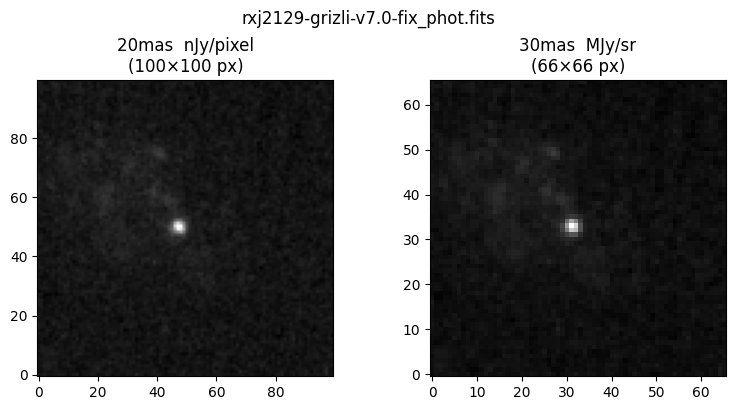

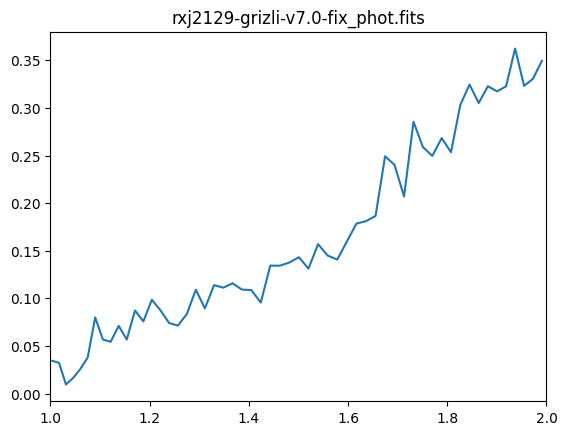

-------------------
j112716p4228-grizli-v7.0-f150w-clear_drc_sci.fits.gz j112716p4228-grizli-v7.0-fix_phot.fits
Number of sources in catalog: 11
Randomly selected source: 151608
20mas cutout shape: (100, 100)
fraction of 0 in cutout: 0.0
30mas cutout shape: (66, 66)
value range (MJy/sr): [-0.0040, 0.0362]


/u/yacheng/conda-envs/stenv/lib/python3.11/site-packages/reproject/common.py:190: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


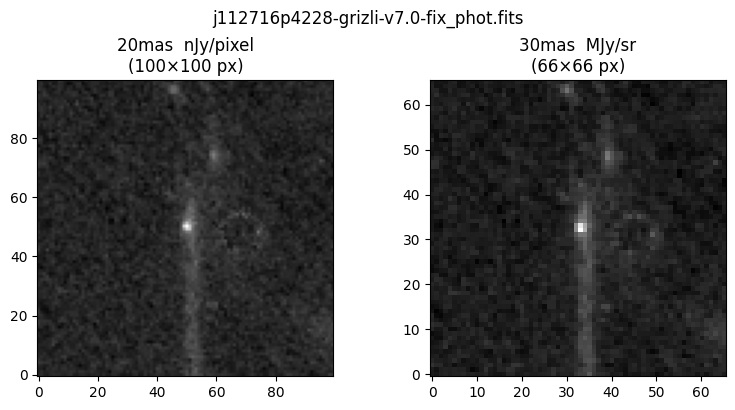

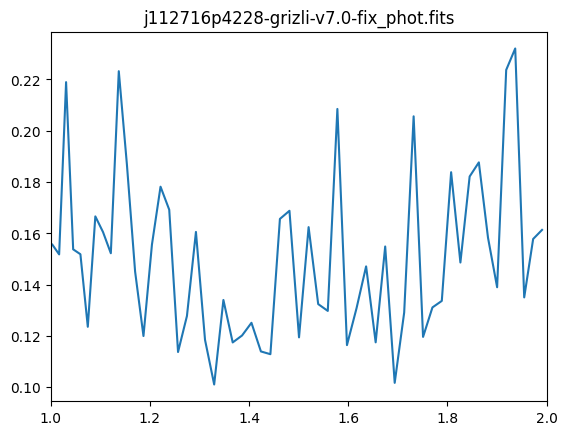

In [66]:
from astropy.io import fits
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from astropy.wcs import WCS
from astropy.table import Table
import numpy as np

scale  = TARGET_MAS / NATIVE_MAS          # 1.5
out_hw = int(HALF_PIX * 2 / scale)       # ~67 pixels at 30mas

# nJy/pixel → MJy/sr 换算系数（在原始 20mas 像素尺度下）
# 1 nJy = 1e-15 MJy；像素面积 = (NATIVE_MAS * 1e-3 arcsec)^2
_pix_arcsec2 = (NATIVE_MAS * 1e-3) ** 2                        # arcsec²
_pix_sr      = _pix_arcsec2 * (np.pi / (180.0 * 3600.0)) ** 2  # sr
NJY_TO_MJY_SR = 1e-15 / _pix_sr   # multiply cutout_nJy_pixel by this → MJy/sr
print(f'nJy/pixel → MJy/sr factor at {NATIVE_MAS}mas: {NJY_TO_MJY_SR:.4f}')

for image, name in tqdm(list(zip(root, root_original))[:20]):
    print('-------------------')
    print(image, name)
    try:
        with fits.open('download_mosaic/'+image.replace('.gz', '')) as hdul:
            hdu = hdul[0]
            catalog_sub = df[df['file_phot'] == name]
            print('Number of sources in catalog:', len(catalog_sub))
            wcs = WCS(hdu.header)
            index = np.random.randint(0, len(catalog_sub))
            print('Randomly selected source:', catalog_sub['objid'].values[index])
            ra  = catalog_sub['ra'].values[index]
            dec = catalog_sub['dec'].values[index]

            # --- 20mas cutout (nJy/pixel, with WCS) ---
            coord = SkyCoord(ra=ra*u_astropy.deg, dec=dec*u_astropy.deg)
            cutout_obj = Cutout2D(hdu.data, coord,
                                  size=(HALF_PIX*2, HALF_PIX*2),
                                  wcs=wcs, mode='partial', fill_value=0.0)
            cutout_20mas = cutout_obj.data          # nJy/pixel
            cutout_wcs   = cutout_obj.wcs
            print('20mas cutout shape:', cutout_20mas.shape)
            print('fraction of 0 in cutout:', np.sum(cutout_20mas == 0) / cutout_20mas.size)

            # --- Convert to MJy/sr before reprojecting ---
            # reproject_exact 对 MJy/sr（surface brightness）是严格正确的：
            # 面积加权平均保留表面亮度；而 nJy/pixel 是积分量，
            # 先转换可以避免面积比补偿，与 COSMOS-Web pipeline 完全统一。
            cutout_sb = cutout_20mas * NJY_TO_MJY_SR   # MJy/sr

            # --- Build output WCS: scaled pixel size, crpix/crval → source at center ---
            out_wcs = cutout_wcs.deepcopy()
            if out_wcs.wcs.has_cd():
                out_wcs.wcs.cd = out_wcs.wcs.cd * scale
            else:
                out_wcs.wcs.cdelt = out_wcs.wcs.cdelt * scale
            out_wcs.wcs.crpix = np.array([out_hw / 2 + 0.5, out_hw / 2 + 0.5])
            out_wcs.wcs.crval = np.array([ra, dec])
            out_wcs.wcs.set()

            # --- Reproject to 30mas (MJy/sr, flux-conserving for surface brightness) ---
            cutout_30mas, _ = reproject_exact(
                (cutout_sb, cutout_wcs),
                out_wcs,
                shape_out=(out_hw, out_hw)
            )   # output unit: MJy/sr, consistent with COSMOS-Web h5 files
            print('30mas cutout shape:', cutout_30mas.shape)
            print(f'value range (MJy/sr): [{np.nanmin(cutout_30mas):.4f}, {np.nanmax(cutout_30mas):.4f}]')

            # --- Plot comparison ---
            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(cutout_20mas, origin='lower', cmap='gray')
            axes[0].set_title(f'20mas  nJy/pixel\n({cutout_20mas.shape[0]}×{cutout_20mas.shape[1]} px)')
            axes[1].imshow(cutout_30mas, origin='lower', cmap='gray')
            axes[1].set_title(f'30mas  MJy/sr\n({cutout_30mas.shape[0]}×{cutout_30mas.shape[1]} px)')
            fig.suptitle(name)
            plt.tight_layout()
            plt.show()

        # --- Spectrum ---
        table = fits.open(f'download/{catalog_sub["file"].values[index]}')[1].data
        wave = table['wave']
        mask = (wave > 1) & (wave < 2)
        wave = wave[mask]
        flux = table['flux'][mask]
        plt.plot(wave, flux)
        plt.xlim(1, 2)
        plt.title(name)
        plt.show()
    except Exception as e:
        print(e)

In [ ]:
!cd /raven/u/yacheng/projects/ssl_outthere/images/JDA
!/u/yacheng/conda-envs/stenv/bin/python build_jda_image_h5.py \
    --num-workers 15 \
    --out jda_spectra_low_image.h5
